<center><a target="_blank" href="https://academy.constructor.org/"><img src=https://lh3.googleusercontent.com/d/1fypIr9T-7ntcsVQFmC2_iMPcsm7h8jXg width="500" style="background:none; border:none; box-shadow:none;" /></a> </center>
<hr />

# <h1 align="center"> Exercise: Introduction to Visualization, Mapping </h1>
<p style="margin-bottom:1cm;"></p>

_____

<center>Constructor Nexademy, 2026</center>


# Visualization Day 1

## Table of contents

*  Exercise 1: Line Chart
*  Exercise 2: Bar Chart
*  Exercise 3: Scatterplot
*  Exercise 4: Heatmap
*  Exercise 5: Transforms
*  Exercise 6: Sort

# Preamble
The exercises for Day 1 are to develop familiarity with the APIs and fluency in the basics of plotting.

In [29]:
# import packages
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# use seaborn style
sns.set()
sns.set_style('darkgrid')

# Read in data

**SNB Money-market Rate Data**

Data on the money-market rates over various terms, including: overnight (`SARON`), call money rate (`1TGT`), 1, 3, 6, and 12-month CHF-denominated loans (`1M`, `3M0`, `6M`, `12M`, respectively), and USD, JPY, GBP, and EUR-denominated loans (`3M1`, `3M2`, `3M3`, and `3M4`, respectively)

Used in Ex 1 and 2

In [31]:
orig_url='https://drive.google.com/file/d/1nAW8z4IHxmLFx1GM5w6QBvsYphluWlhz/view?usp=sharing'
file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id

snb_df = pd.read_csv(dwn_url, sep=";", skiprows=2)
snb_df = snb_df.rename({'D0': 'Instrument'}, axis=1)
snb_df['Date'] = pd.to_datetime(snb_df['Date'])
snb_df = snb_df.set_index(['Date', 'Instrument']).unstack()['Value']
term_order = ['SARON', '1TGT', '1M', 'EG3M', '3M0', '3M1', '3M2', '3M3', '3M4', '6M', '12M']
snb_df = snb_df[term_order]
snb_df.head()

Instrument,SARON,1TGT,1M,EG3M,3M0,3M1,3M2,3M3,3M4,6M,12M
Date,,,,,,,,,,,
1972-01-01,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-02-01,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-03-01,NaN,0.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-04-01,NaN,0.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-05-01,NaN,1.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**MPG Data**

Data about a selection of automobiles in two years: 1999 and 2008. Includes information about the manufacturer and model of each car, as well as data on the type of car (`class`), the size of the engine (`displ`, `cyl`), the type of transmission (`trans`), and city and highway fuel efficiency (`cty`, `hwy`) in miles/gallon of fuel units.

Used in Ex 3, 4, 5

In [32]:
orig_url='https://drive.google.com/file/d/1NYe6jyM1g8PpER3TffWjynBpuAWK14Jx/view?usp=sharing'
file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id

mpg_df = pd.read_csv(dwn_url)
mpg_df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


**Antibiotics Data**

Data on the dosage of `antibiotic` (`mic` or _minimum inhibitory concentration_ in $\mu$g/ml) necessary to kill various `bacteria`, and the `gram`-type of each bacterium.

Used in Ex 4, 5, 6

In [33]:
orig_url='https://drive.google.com/file/d/1if_OcwnWo9INlTlKAEUJkeuJXDWpHPVB/view?usp=sharing'
file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id

antibiotics_df = pd.read_json(dwn_url, orient='records').set_index(['bacteria', 'gram'])
antibiotics_df = antibiotics_df.stack().reset_index()
# mic = minimum inhibitory concentration
antibiotics_df.columns = ['bacteria', 'gram', 'antibiotic', 'mic']
# assign an id to each bacterium
bid_dict = {b:i for i, b in enumerate(sorted(pd.unique(antibiotics_df['bacteria'])))}
antibiotics_df['bid'] = antibiotics_df.apply(lambda x: bid_dict[x['bacteria']], 1)
# extract the genus of each bacterium
antibiotics_df['genus'] = antibiotics_df['bacteria'].apply(lambda x: x.split(" ")[0])
antibiotics_df.head()

,bacteria,gram,antibiotic,mic,bid,genus
0,Mycobacterium tuberculosis,negative,penicillin,800.0,6,Mycobacterium
1,Mycobacterium tuberculosis,negative,streptomycin,5.0,6,Mycobacterium
2,Mycobacterium tuberculosis,negative,neomycin,2.0,6,Mycobacterium
3,Salmonella schottmuelleri,negative,penicillin,10.0,10,Salmonella
4,Salmonella schottmuelleri,negative,streptomycin,0.8,10,Salmonella


# Basic Plotting

## Ex. 1: Line Chart

A line chart is a standard way of showing the evolution of a variable over time. A line chart can be realized using the `plot` function in pandas or the `plot` function of a matplotlib `ax` or `pyplot` object.

### Ex. 1.1

The snb_df includes a `1TGT` column for of rates for tomorrow-next loans. Plot a line chart of this column.

In [35]:


df = pd.read_csv(r'/home/soraan/Desktop/karzanmahmoudi/03_Visualization/day1/data/snb-data-zimoma-en-all-20200901_1437.csv', sep=";", skiprows=2)

print(df.head(5))


      Date     D0  Value
0  1972-01  SARON    NaN
1  1972-01   1TGT    0.0
2  1972-01   EG3M    NaN
3  1972-01     1M    NaN
4  1972-01    3M0    NaN


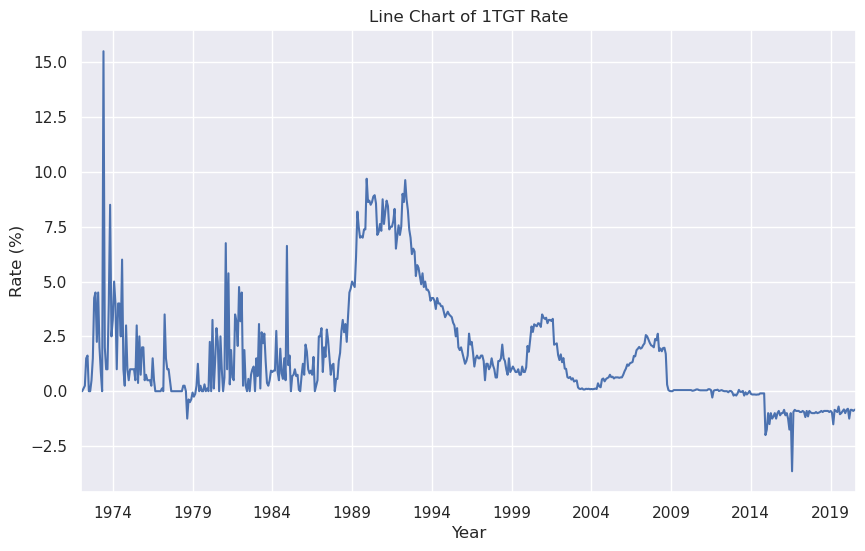

In [37]:
#rename d0 to intru because its not clear 
df = df.rename({'D0': 'Instrument'}, axis=1)

#arrange o sorting data with this func
df['Date'] = pd.to_datetime(df['Date'])
snb_df = df.set_index(['Date', 'Instrument']).unstack()['Value']


# a jadwale faghatITG ro enterkhab kon o plot yani bekesh
snb_df['1TGT'].plot(figsize=(10, 6))

plt.title('Line Chart of 1TGT Rate')
plt.ylabel('Rate (%)')
plt.xlabel('Year')
plt.show()


### Ex 1.2

Add a title and y-axis label to the plot from Ex 1.1. The title should be `Swiss Call Money Rate`. The y-axis label should be "Yield (%)".

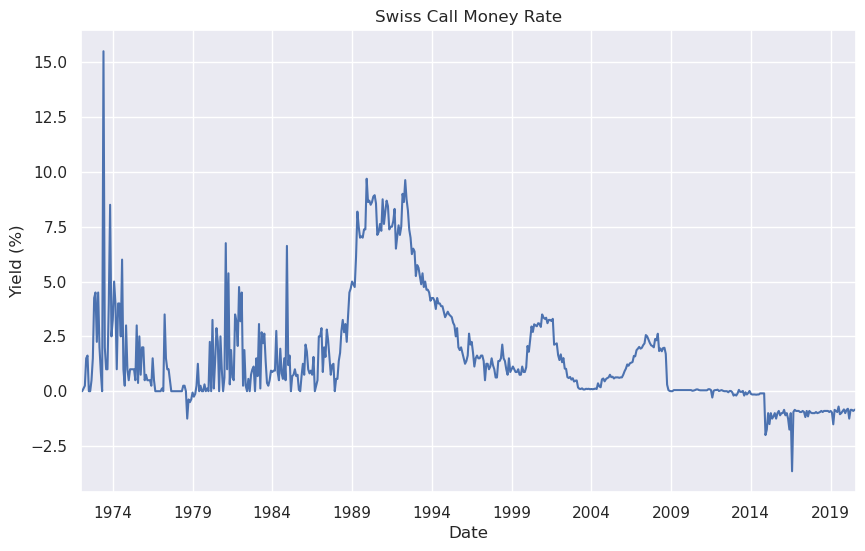

In [41]:
# 1. Rasm kardan hamon nemoodar ghabli
snb_df['1TGT'].plot(figsize=(10, 6))

# 2. Ezafe kardane Onvan (Title) dar balaye nemoodar
plt.title ('Swiss Call Money Rate')

# 3. Esme mehvare amoodi (Y-axis label)
plt.ylabel('Yield (%)')

# 4. Namayeshe nahaee
plt.show()

## Ex. 2: Bar Chart

A bar chart can also show the evolution of a variable over time. This can be a good option if the data are discrete rather than continous.

A bar plot can be created using the pandas `plot.bar` function or the `bar` function on a matplotlib `ax` or `pyplot` object.

### Ex 2.1

Using the same data is an Ex.1, plot a bar chart of the *average 1TGT rate per year*. Make the figure 10x6 inches.

Step 1, group the data by year and compute the mean.

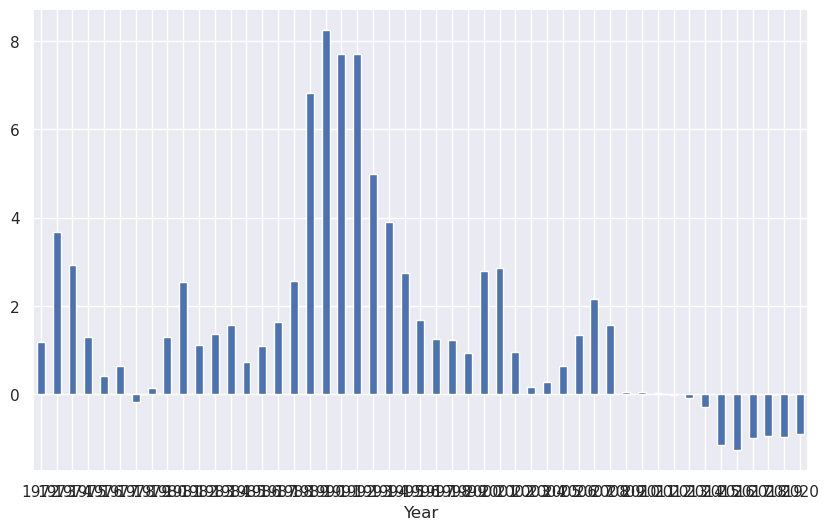

In [ ]:
# 1. Sakhtane ye sotoone jadid baraye Saal
# Inja be sotoone Date migim faghat Saal (year) ro dar biar
snb_df_reset = snb_df.reset_index()
snb_df_reset['Year'] = snb_df_reset['Date'].dt.year

# 2. Mohasebe-ye Miangine saalane ba GroupBy
# In dastoor tamame 12 mahe har saal ro yeki mikone o miangin migire
snb_yearly_mean = snb_df_reset.groupby('Year')['1TGT'].mean()

# 3. Rasm kardane Bar Chart (10x6 inch)
snb_yearly_mean.plot(kind='bar', figsize=(10, 6))
#plt.xticks(rotation=0)

# 4. Namayeshe nahaee
plt.show()

use another code to sorting years in chart

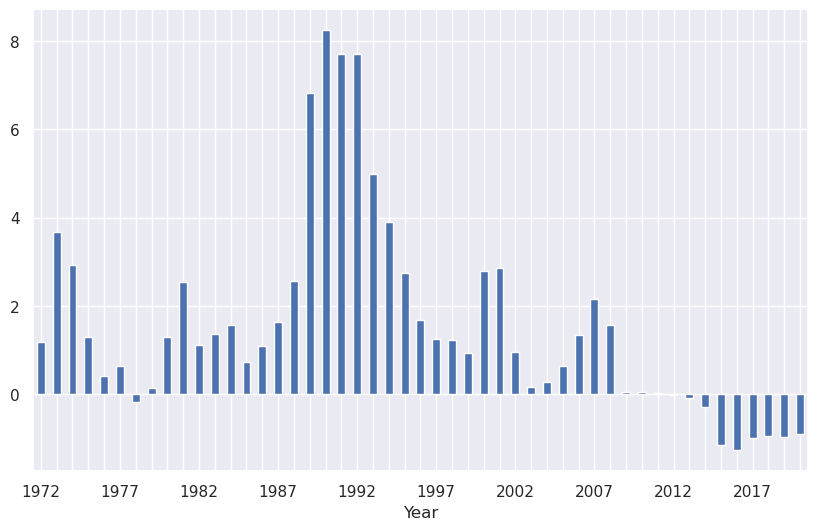

In [48]:
# 1. Rasm kardane hamon nemoodar
ax = snb_yearly_mean.plot(kind='bar', figsize=(10, 6))

# 2. Afogghi kardane neveshte-haye zir (Rotation = 0)
plt.xticks(rotation=0)

# 3. Faghat neshoon dadane har 5 saal yekbar (ta kholvat beshe)
# Inja migim az avali shoroo kon, 5 ta 5 ta boro jelo
for i, t in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        t.set_visible(False)

plt.show()

Step 2, plot the mean `1TGT` series.

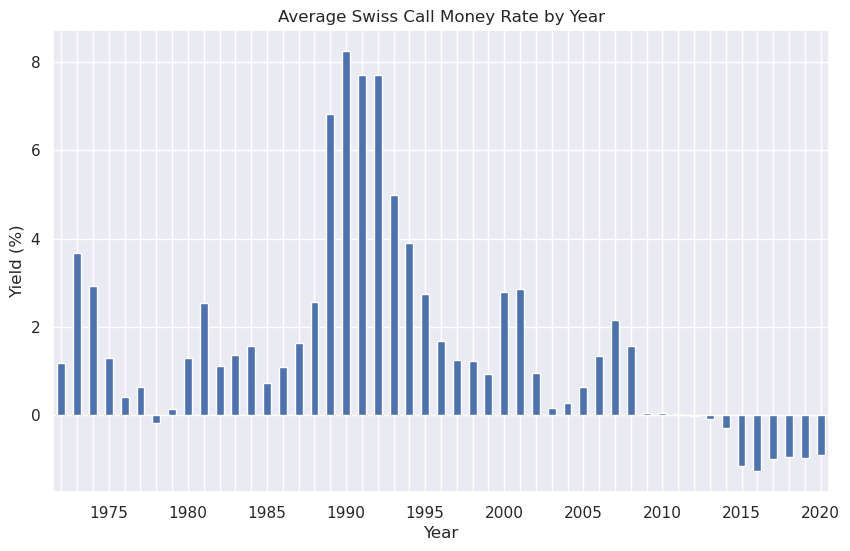

## Ex 2.2

Take the plot from Ex 2.1 and make the following changes:
- Add a title: `Average Swiss Call Money Rate by Year`
- Set the y-axis label to `Yield (%)`.
- Only label every 5th year between 1975 to 2020 (e.g., 1975, 1980, 1985, etc.) on the x-axis. The other years should have no label.

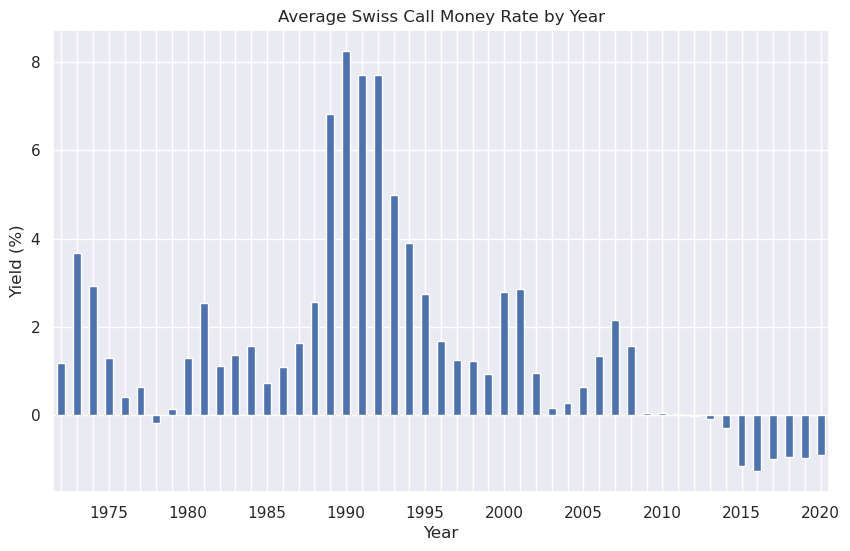

In [53]:
# code your solution here

# 1. Rasm kardane Bar Chart ba miangin-haye salane ke ghablan hesab kardim
ax = snb_yearly_mean.plot(kind='bar', figsize=(10, 6))

# 2. Add kardane Title va Label-e mehvare Y (Ex 2.2)
plt.title('Average Swiss Call Money Rate by Year')
plt.ylabel('Yield (%)')

# 3. Kholvat kardane Saal-haye mehvare X (Faghat har 5 saal yebar)
labels = ax.get_xticklabels()
for i, label in enumerate(labels):
    # Gereftane adade saal az ruye neveshte-ye zir-e nemoodar
    year_val = int(label.get_text())
    
    # Age saal bar 5 bakhsh-pazir nabood, makhfish kon
    if year_val % 5 != 0:
        label.set_visible(False)

# 4. Afogghi kardane saal-ha baraye khonashode-ye bishtar
plt.xticks(rotation=0)

# 5. Namayeshe nahaee
plt.show()

## Ex 3: Scatterplot

A scatterplot can be used to show any relationship between two variables.

### Ex 3.1

Using the `mpg_df` dataframe, make a scatterplot with `hwy` on the x-axis and `cty` on the y-axis. Give the plot the title `Highway vs. City Fuel Mileage`, and label the x-axis `Highway` and the y-axis `City`.

In [55]:
# code your solution here


mpg_df = pd.read_csv(r'/home/soraan/Desktop/karzanmahmoudi/03_Visualization/day1/data/mpg.csv')

print(mpg_df.head(5))


  manufacturer model  displ  year  cyl       trans drv  cty  hwy fl    class
0         audi    a4    1.8  1999    4    auto(l5)   f   18   29  p  compact
1         audi    a4    1.8  1999    4  manual(m5)   f   21   29  p  compact
2         audi    a4    2.0  2008    4  manual(m6)   f   20   31  p  compact
3         audi    a4    2.0  2008    4    auto(av)   f   21   30  p  compact
4         audi    a4    2.8  1999    6    auto(l5)   f   16   26  p  compact


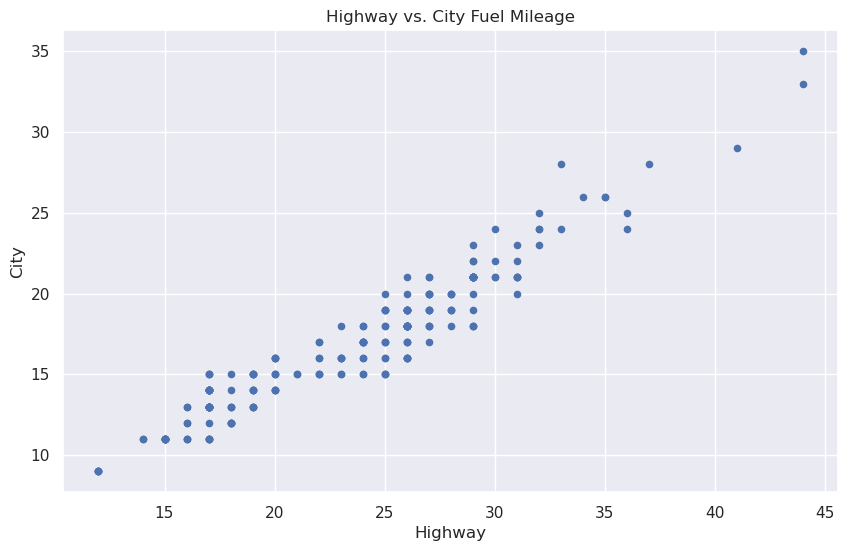

In [ ]:
#mikham bebiim bein motaghaiera rabetei hast ya na 

# 1. Rasm kardane Scatterplot
# x mehvare afogghi (hwy), y mehvare amoodi (cty)
mpg_df.plot.scatter(x='hwy', y='cty', figsize=(10, 6))

# 2. Add kardane Onvan (Title)
plt.title('Highway vs. City Fuel Mileage')

# 3. Label gozari baraye mehvar-ha (Ex 3.1)
plt.xlabel('Highway')
plt.ylabel('City')

# 4. Namayeshe nahaee
plt.show()


### Ex 3.2

As in 3.1 use the `mpg_df` dataframe to make a scatterplot with `hwy` on the x-axis and `cty` on the y-axis.
This time, use different mark shapes for cars from the year 1999 and 2008. For example, draw cars from 1999 as +'s, those from 2008 as x's.

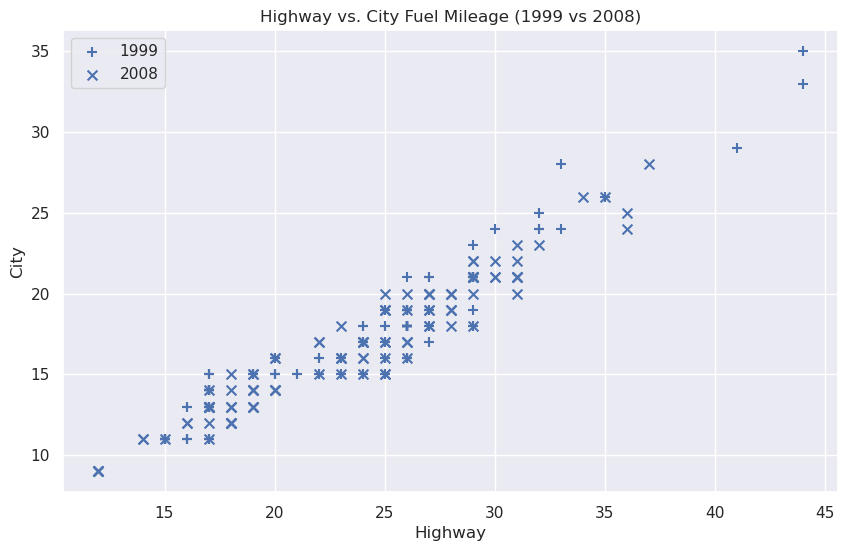

In [ ]:
# code your solution here

#tavafot mashinaie 1998 o 2008 

# 1. Joda kardane dade-haye saal-e 1999 va 2008
df_1999 = mpg_df[mpg_df['year'] == 1999]
df_2008 = mpg_df[mpg_df['year'] == 2008]

# 2. Rasm kardane noghte-haye saal-e 1999 ba alamate '+'
# 'ax' mesle ye safe-ye naghashi-ye moshtarake ke har do ro roosh mikeshim

#  s = 50 vase size chon deafaultesh kochike inja migim sizo bozorg on ro 50 
ax = df_1999.plot.scatter(x='hwy', y='cty', marker='+', s=50, label='1999', figsize=(10, 6))

# 3. Rasm kardane noghte-haye saal-e 2008 rooye hamon safe (ax=ax) ba alamate 'x'
df_2008.plot.scatter(x='hwy', y='cty', marker='x', s=50, label='2008', ax=ax)

# 4. Add kardane Onvan va Label-ha
plt.title('Highway vs. City Fuel Mileage (1999 vs 2008)')
plt.xlabel('Highway')
plt.ylabel('City')

# 5. Namayesh
plt.show()


### Ex 3.3

As in 3.1 use the `mpg_df` dataframe to make a scatterplot with `hwy` on the x-axis and `cty` on the y-axis, using the default mark shapes (dots).
This time, color all marks representing data from the year 1999 in a different color than those from 2008. Set the `alpha` of the marks to 0.5. Why are some dots neither of the two colors you explicitly selected?

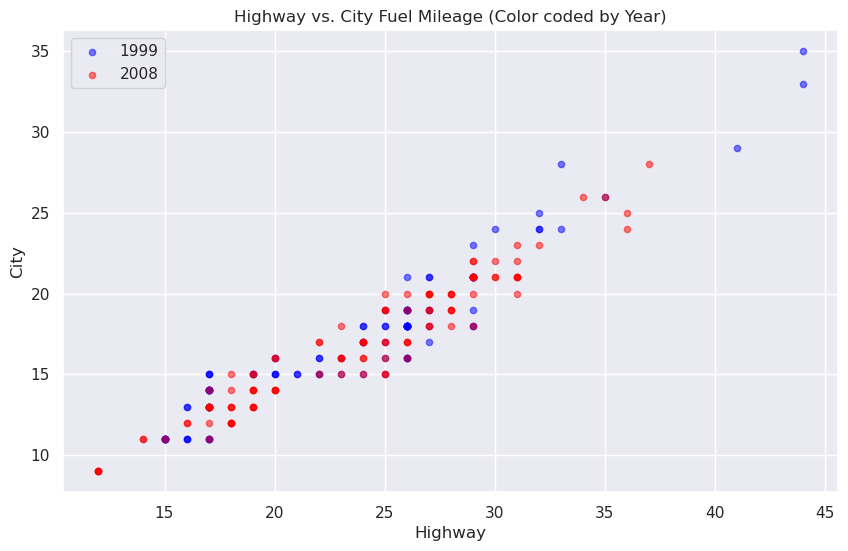

In [58]:
# code your solution here


# 1. Joda kardane dade-haye saal-e 1999 va 2008
df_1999 = mpg_df[mpg_df['year'] == 1999]
df_2008 = mpg_df[mpg_df['year'] == 2008]

# 2. Rasm kardane 1999 ba range abi (blue) va alpha=0.5
ax = df_1999.plot.scatter(x='hwy', y='cty', color='blue', alpha=0.5, label='1999', figsize=(10, 6))

# 3. Rasm kardane 2008 rooye hamon safe (ax=ax) ba range ghermez (red) va alpha=0.5
df_2008.plot.scatter(x='hwy', y='cty', color='red', alpha=0.5, label='2008', ax=ax)

# 4. Add kardane Onvan va Label-ha
plt.title('Highway vs. City Fuel Mileage (Color coded by Year)')
plt.xlabel('Highway')
plt.ylabel('City')

# 5. Namayesh
plt.show()

### Ex 3.4

As in 3.3 use the `mpg_df` dataframe to make a scatterplot with `hwy` on the x-axis and `cty` on the y-axis. Again, color all marks representing data from the year 1999 in a different color than those from 2008, this time using two colors from the ColorBrewer `Dark2` palette.

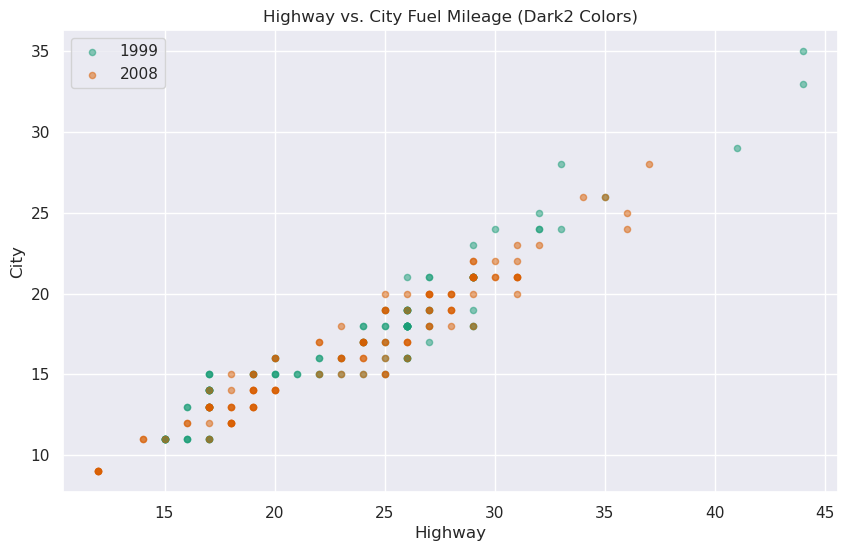

In [59]:
# code your solution here



# inja desgin ro herfeitar mikoinm az pakete dark 2 
# 1. Gereftane range-haye Dark2 az Matplotlib
# Inja ma 2 ta rang az in palet ro barmidarim
cmap = plt.get_cmap('Dark2')
color_1999 = cmap(0) # Range avale palet
color_2008 = cmap(1) # Range dovome palet

# 2. Joda kardane dade-ha (mesle ghabl)
df_1999 = mpg_df[mpg_df['year'] == 1999]
df_2008 = mpg_df[mpg_df['year'] == 2008]

# 3. Rasm kardane 1999 ba range avale Dark2
ax = df_1999.plot.scatter(x='hwy', y='cty', color=color_1999, alpha=0.5, label='1999', figsize=(10, 6))

# 4. Rasm kardane 2008 ba range dovome Dark2 rooye hamon safe
df_2008.plot.scatter(x='hwy', y='cty', color=color_2008, alpha=0.5, label='2008', ax=ax)

# 5. Add kardane Onvan va Label-ha
plt.title('Highway vs. City Fuel Mileage (Dark2 Colors)')
plt.xlabel('Highway')
plt.ylabel('City')

# 6. Namayesh
plt.show()

### Ex 3.5
Again, use the `mpg_df` dataframe to make a scatterplot with `hwy` on the x-axis and `cty` on the y-axis.
This time, map the `class` column of the dataframe to color. You will need a palette with seven (7) colors. All `subcompact` cars should be one color, all `compact` cars another color, etc.

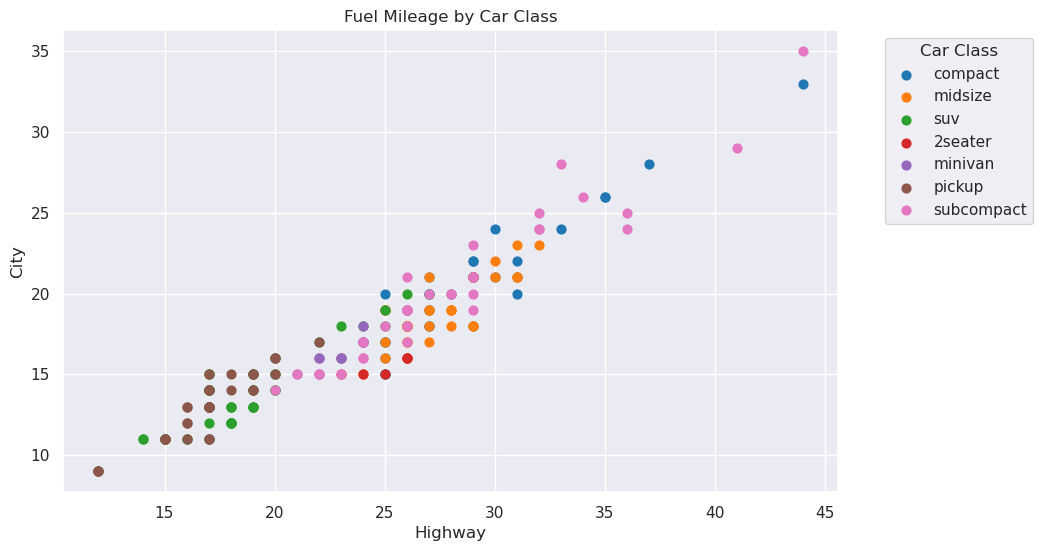

In [60]:
# code your solution here


# inja mashinari bar asalan klaso modelo ina sorting mikoinm morata mikonim 


# 1. Entekhab kardane ye palet ba 7 rang
# Palet-e 'tab10' baraye in kar aliye chon 10 ta range motamayeze standard dare
cmap = plt.get_cmap('tab10')

# 2. Gereftane liste model-haye mashin (Unique classes)
# In dastoor 7 model-e mashin ro peyda mikone (SUV, Compact, etc.)
car_classes = mpg_df['class'].unique()

# 3. Sakhtane ye safe-ye khali baraye rasm (ax)
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Halghe baraye rasm kardane har 'class' ba range makhsoose khodesh
for i, car_class in enumerate(car_classes):
    # Joda kardane dade-haye har model
    temp_df = mpg_df[mpg_df['class'] == car_class]
    
    # Rasm kardan ba range i-om az palet
    temp_df.plot.scatter(x='hwy', y='cty', 
                         color=cmap(i), 
                         label=car_class, 
                         ax=ax, s=40)

# 5. Add kardane Onvan va Label-ha
plt.title('Fuel Mileage by Car Class')
plt.xlabel('Highway')
plt.ylabel('City')
plt.legend(title="Car Class", bbox_to_anchor=(1.05, 1), loc='upper left') # Legend ro mibarim biroon ke jash beshe

plt.show()


### Ex 3.6
Make the same plot as in 3.5, but use different mark shapes for cars from the year 1999 vs. 2008. For example, draw cars from 1999 as +'s, those from 2008 as x's.

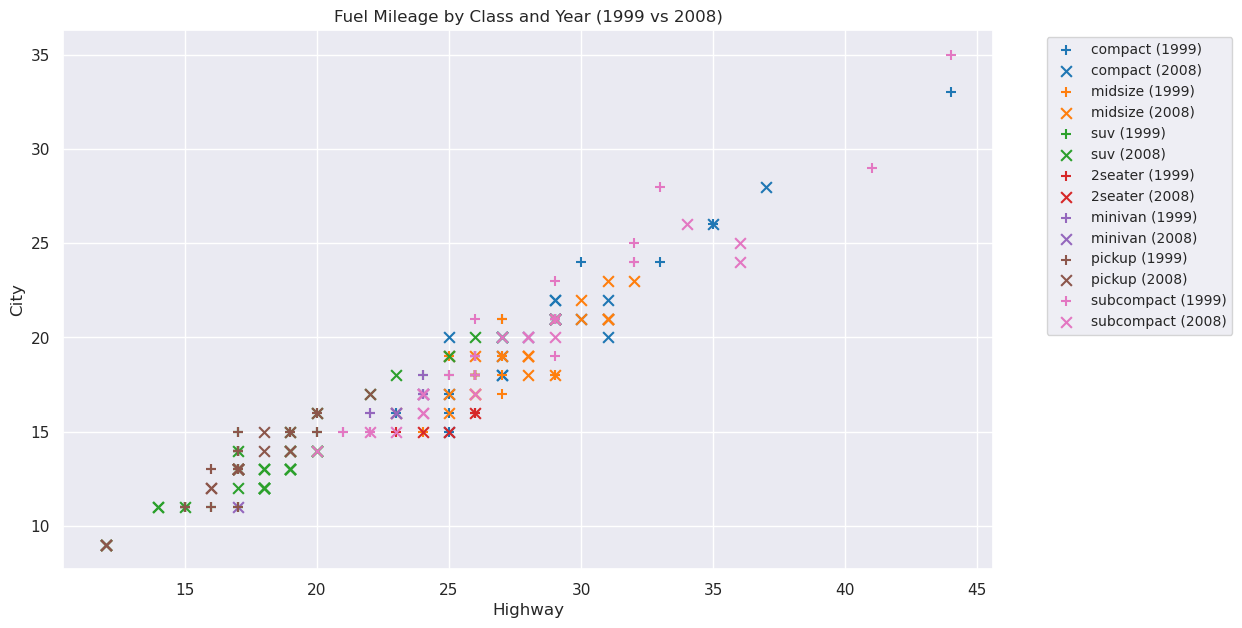

In [61]:
# code your solution here


# bar asase klas behesh rang midim o bar asas sal sakht alamt miim 

# 1. Entekhab kardane palet-e 7 rangi baraye class-ha
cmap = plt.get_cmap('tab10')
car_classes = mpg_df['class'].unique()

# 2. Sakhtane safe-ye asli-ye nemoodar
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Halghe baraye rasm kardane noghte-ha
for i, car_class in enumerate(car_classes):
    # Joda kardane dade-haye har class
    class_df = mpg_df[mpg_df['class'] == car_class]
    
    # --- A: Rasm kardane saal-e 1999 ba alamate '+' ---
    df_1999 = class_df[class_df['year'] == 1999]
    df_1999.plot.scatter(x='hwy', y='cty', 
                         color=cmap(i), marker='+', s=60,
                         label=f'{car_class} (1999)', ax=ax)
    
    # --- B: Rasm kardane saal-e 2008 ba alamate 'x' ---
    df_2008 = class_df[class_df['year'] == 2008]
    df_2008.plot.scatter(x='hwy', y='cty', 
                         color=cmap(i), marker='x', s=60,
                         label=f'{car_class} (2008)', ax=ax)

# 4. Tanzimate nahaee (Title va Label)
plt.title('Fuel Mileage by Class and Year (1999 vs 2008)')
plt.xlabel('Highway')
plt.ylabel('City')

# 5. Legend ro mibarim biroon chon kheili bozorg mishe (14 ta item!)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')

plt.show()

## Ex 4: Heatmap

A heatmap can be used to display three variables of data, two mapped to x and y position of a mark, the third mapped to color. The seaborn `heatmap` function provides an easy to way make heatmaps.

### Ex 4.1

Using the `antibiotics_df` dataframe, make a heatmap with `antibiotic` on the x-axis and `bacteria` on the y-axis, and the `mic` column represented using color. Label the x-axis `Bacterium`, the y-axis `Antibiotic`, and give the entire plot the title `MIC of Antibiotics`.

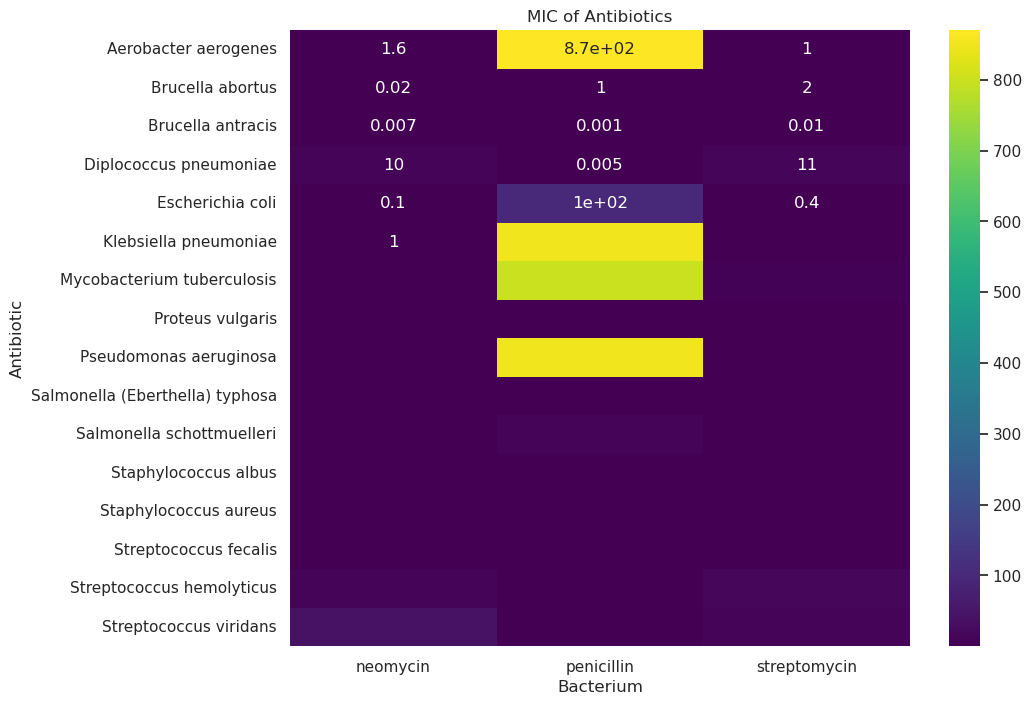

In [64]:
# code your solution here



# 1. Sakhtane jadval (Pivot)
# Baktri-ha mishan radif (index) va Antibiotic-ha mishan sotoon (columns)
pivot_df = antibiotics_df.pivot(index='bacteria', columns='antibiotic', values='mic')

# 2. Rasm kardane Heatmap
plt.figure(figsize=(10, 8))
# annot=True adad-ha ro dakhele khoone-ha neshon mide
sns.heatmap(pivot_df, annot=True, cmap='viridis')

# 3. Gozashtane Onvan va Label-ha (Daghighan tebghe soale ostad)
plt.title('MIC of Antibiotics')
plt.xlabel('Bacterium')  
plt.ylabel('Antibiotic') 

# 4. Namayesh
plt.show()


### Ex 4.2

As in Ex 4.1, use the `antibiotics_df` dataframe to make a heatmap with `antibiotic` on the x-axis and `bacteria` on the y-axis, and the `mic` column represented using color. This time, use a log scale for the `mic` column / color mapping.

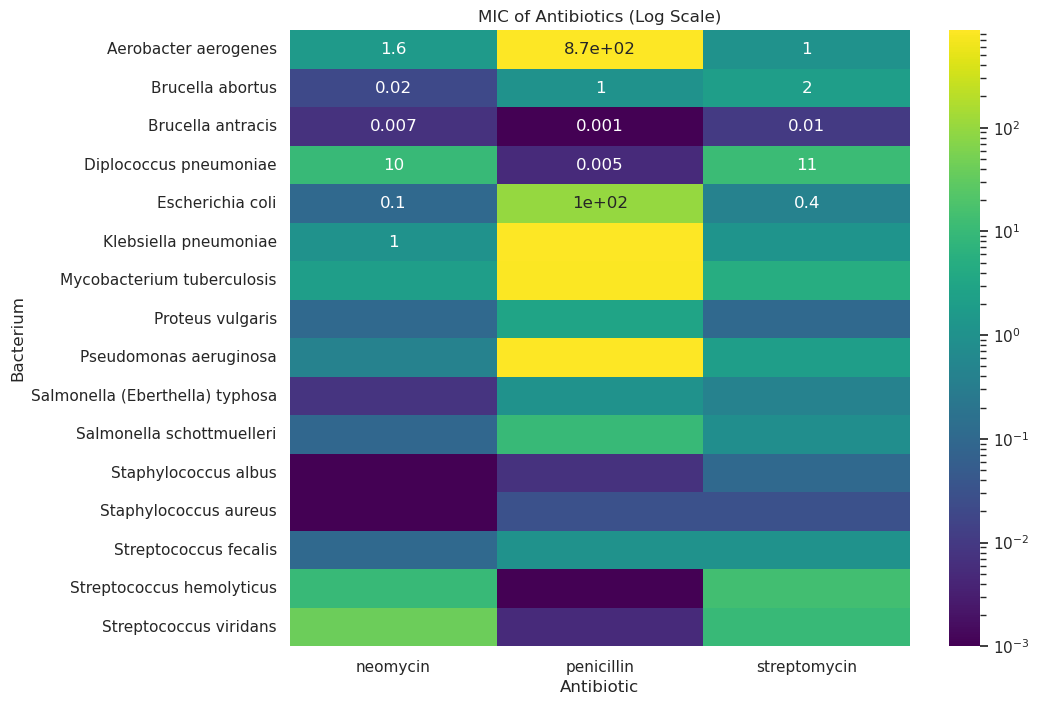

In [66]:
# code your solution here


from matplotlib.colors import LogNorm  
# In abzar jadid baraye Log Scale ast

# 1. Sakhtane jadval (Pivot) mesle tamrine ghabl
pivot_df = antibiotics_df.pivot(index='bacteria', columns='antibiotic', values='mic')

# 2. Rasm kardane Heatmap ba Log Scale
plt.figure(figsize=(10, 8))
# ba ezafe kardane norm=LogNorm() be python migim az meghyase logaritmi estefade kon
sns.heatmap(pivot_df, annot=True, cmap='viridis', norm=LogNorm())

# 3. Onvan va Label-ha
plt.title('MIC of Antibiotics (Log Scale)')
plt.xlabel('Antibiotic')
plt.ylabel('Bacterium')

# 4. Namayeshe nahaee
plt.show()


## Ex 5: Transforms

Data transformations can make a chart easier to understand and are necessary to even be able to present the data in some cases.

### Ex 5.1

Using the `antibiotics_df` dataframe, plot the `mic` column for `penicillin` as a bar chart. Sort the values in descending order to make visualization easier to interpret.

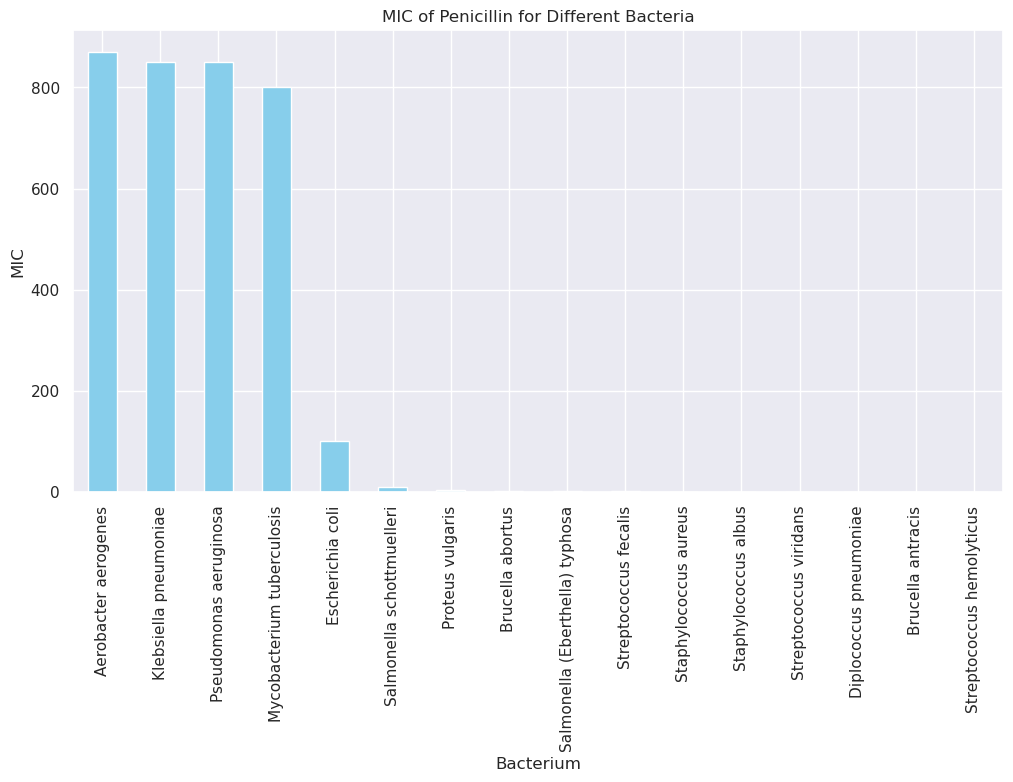

In [ ]:
# code your solution here


# tasire pnicilin roie bakteriha bar asas ghad 


# 1. Joda kardane dade-haye marboot be 'penicillin'
df_penicillin = antibiotics_df[antibiotics_df['antibiotic'] == 'penicillin']

# 2. Moratab kardane adad-ha az bozorg be koochik (Descending order)
df_pen_sorted = df_penicillin.sort_values('mic', ascending=False)

# 3. Rasm kardane nemoodar sotooni (Bar Chart)
# x = esme bacteria, y = adade mic
df_pen_sorted.plot.bar(x='bacteria', y='mic', figsize=(12, 6), color='skyblue', legend=False)

# 4. Gozashtane Onvan va Label-ha baraye mehvar-ha
plt.title('MIC of Penicillin for Different Bacteria')
plt.xlabel('Bacterium')
plt.ylabel('MIC')

# 5. Namayeshe nahaee
plt.show()


### Ex 5.2

Make the same visualization as in 5.1, but use a log scale for the y-axis.




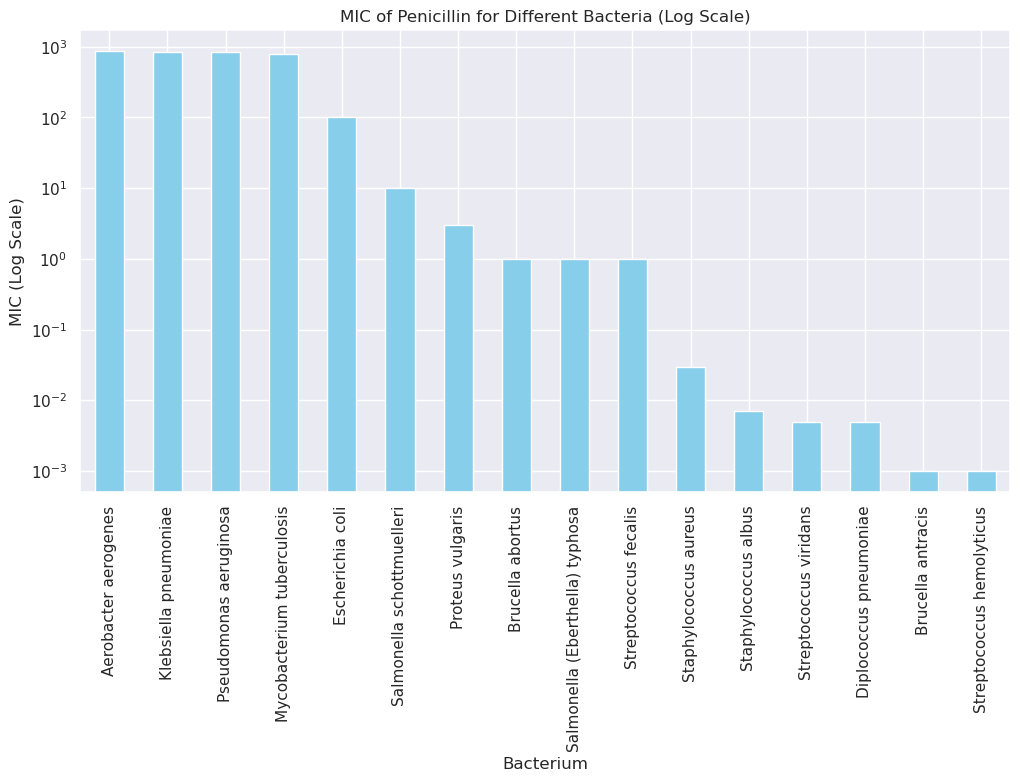

In [68]:
# code your solution here



# 1. Joda kardane dade-haye 'penicillin'
df_penicillin = antibiotics_df[antibiotics_df['antibiotic'] == 'penicillin']

# 2. Moratab kardane adad-ha az bozorg be koochik
df_pen_sorted = df_penicillin.sort_values('mic', ascending=False)

# 3. Rasm kardane Bar Chart ba log scale
# Ezafe kardane 'logy=True' baes mishe mehvare Y logaritmi beshe
df_pen_sorted.plot.bar(x='bacteria', y='mic', figsize=(12, 6), color='skyblue', logy=True, legend=False)

# 4. Onvan va Label-ha
plt.title('MIC of Penicillin for Different Bacteria (Log Scale)')
plt.xlabel('Bacterium')
plt.ylabel('MIC (Log Scale)')

# 5. Namayeshe nahaee
plt.show()

### Ex 5.3

Make the same visualization as in 5.2, but invert the y-axis so it goes from 1000 to 0.001, where the shortest bars represent a dosage of 1000 $\mu$g/ml. What is an appropriate label for the y-axis?

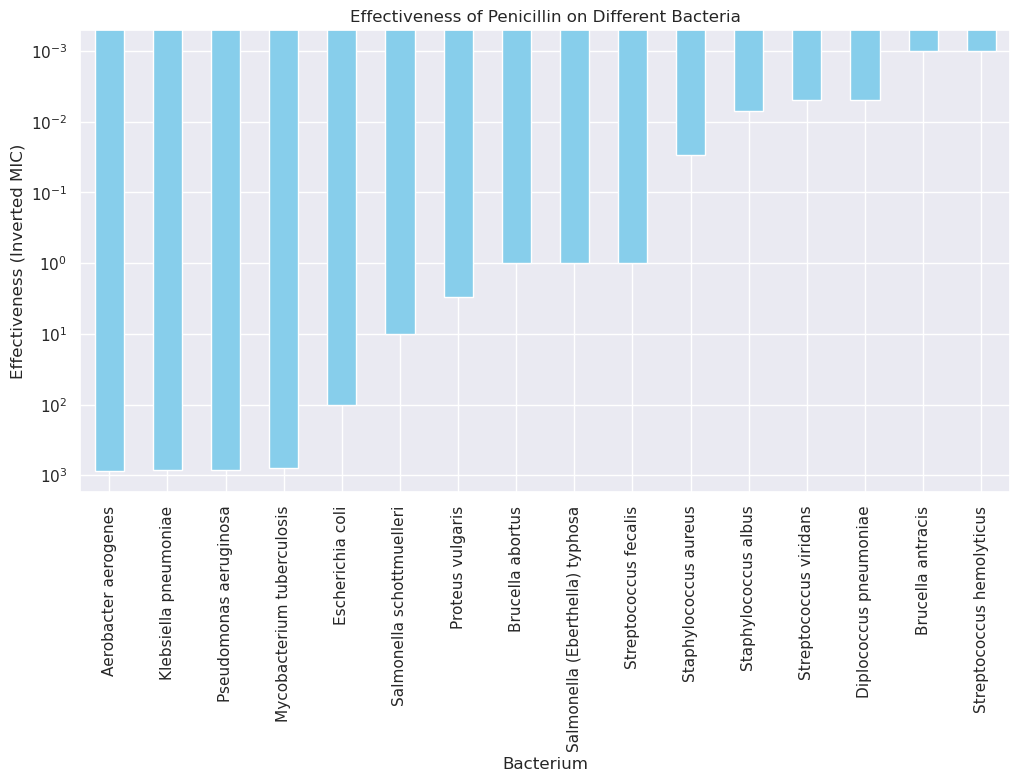

In [ ]:
# code your solution here


# 1. Joda kardane dade-haye 'penicillin' va moratab kardane anha
df_penicillin = antibiotics_df[antibiotics_df['antibiotic'] == 'penicillin']
df_pen_sorted = df_penicillin.sort_values('mic', ascending=False)

# 2. Rasm kardane Bar Chart ba log scale
# Inja kharoji ro mirizim too 'ax' ta betoonim dastkoresh konim
ax = df_pen_sorted.plot.bar(x='bacteria', y='mic', figsize=(12, 6), color='skyblue', logy=True, legend=False)

# 3. Baraks kardane mehvare Y (Invert Y-axis) - Bakhshe jadide tamrin
ax.invert_yaxis()

# 4. Onvan va Label-ha
plt.title('Effectiveness of Penicillin on Different Bacteria')
plt.xlabel('Bacterium')

# Javabe soale ostad baraye Label-e mehvare Y:
plt.ylabel('Effectiveness (Inverted MIC)')

# 5. Namayeshe nahaee
plt.show()

In the context of antibiotics, the lower the MIC value, the stronger the drug is and the easier it kills the bacteria. When we invert the axis, the taller bars now represent the "higher effectiveness" of the drug. Therefore, the best label for the Y-axis would be Effectiveness or Bacterial Susceptibility.

Too bahse antibiotic-ha, harchi adade MIC kamtar bashe, yani oon daroo ghavitare va bacteria ro rahat-tar mikoshe. Vaghti mehvar ro baraks mikonim, hala sotoon-haye boland-tar neshon-dahandeye "tasire bishtar"-e daroo hastan. Pas behtarin esm (Label) baraye mehvare Y mitoone Effectiveness (mizane tasir-gozari) ya Bacterial Susceptibility (hasasiyate bacteria) bashe.   

### Ex 5.4

Take the solution from 5.3, but additionally color the gram positive bacteria differently from the gram negative bacteria.

Step 1, create a data frame that contains the MIC of penicillin and the gram of each bacterium

In [ ]:
# try to solve this yourself. If you are stuck, uncomment the next line and execute this cell
# %load fragment-5.4.1.py




In [70]:
# 1. Joda kardane dade-haye 'penicillin' az kole dade-ha
df_penicillin = antibiotics_df[antibiotics_df['antibiotic'] == 'penicillin']

# 2. Sakhtane ye dataframe jadid ke faghat 3 ta sotoon (columns) ke mikhaim ro dashte bashe
# ['bacteria', 'gram', 'mic']
df_pen_step1 = df_penicillin[['bacteria', 'gram', 'mic']]

# 3. Baraye inke bebinim dorost kar karde, 5 taye aval ro neshon midim
print(df_pen_step1.head())

                      bacteria      gram    mic
0   Mycobacterium tuberculosis  negative  800.0
3    Salmonella schottmuelleri  negative   10.0
6             Proteus vulgaris  negative    3.0
9        Klebsiella pneumoniae  negative  850.0
12            Brucella abortus  negative    1.0


Step 2, plot



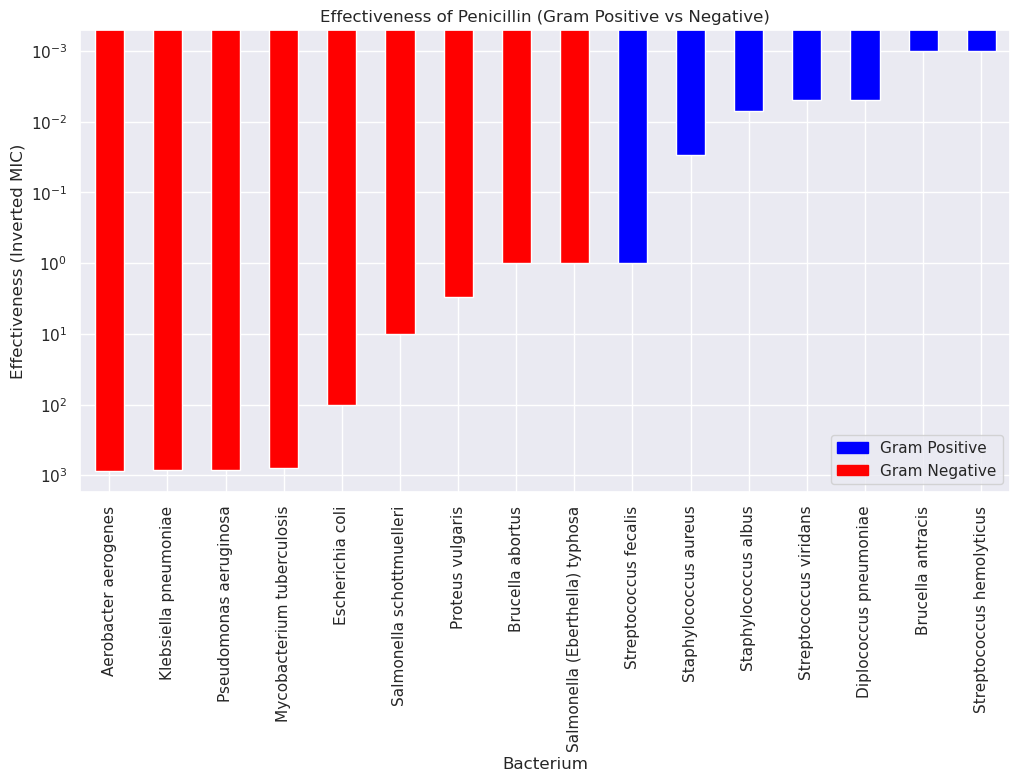

In [72]:
# code your solution here

import matplotlib.patches as mpatches

# 1. Moratab kardane dade-ha az bozorg be koochik (Descending order)
df_pen_sorted = df_pen_step1.sort_values('mic', ascending=False)

# 2. Sakhtane liste rang-ha bar asase mosbat/manfi boodane 'gram'
# positive = blue (abi), negative = red (ghermez)
colors = ['blue' if gram == 'positive' else 'red' for gram in df_pen_sorted['gram']]

# 3. Rasm kardane Bar Chart
# Ba logy=True mehvare Y ro logaritmi mikonim va rang-haye jadid ro midim
ax = df_pen_sorted.plot.bar(x='bacteria', y='mic', color=colors, logy=True, figsize=(12, 6), legend=False)

# 4. Baraks kardane mehvare Y (Invert Y-axis) ta daroohaye ghavitar bolandtar beshan
ax.invert_yaxis()

# 5. Onvan va Label-ha
plt.title('Effectiveness of Penicillin (Gram Positive vs Negative)')
plt.xlabel('Bacterium')
plt.ylabel('Effectiveness (Inverted MIC)')

# 6. Sakhtane rahnamaye rang-ha (Legend) baraye inke moshakhas she har rang chie
pos_patch = mpatches.Patch(color='blue', label='Gram Positive')
neg_patch = mpatches.Patch(color='red', label='Gram Negative')
plt.legend(handles=[pos_patch, neg_patch])

# 7. Namayeshe nahaee
plt.show()

## Ex 6: Sort

### Ex 6.1

Redo the heatmap from 4.2, this time sort the rows by dosage of `neomycin` in ascending order. This will structure and make it easier to interpret the plot.

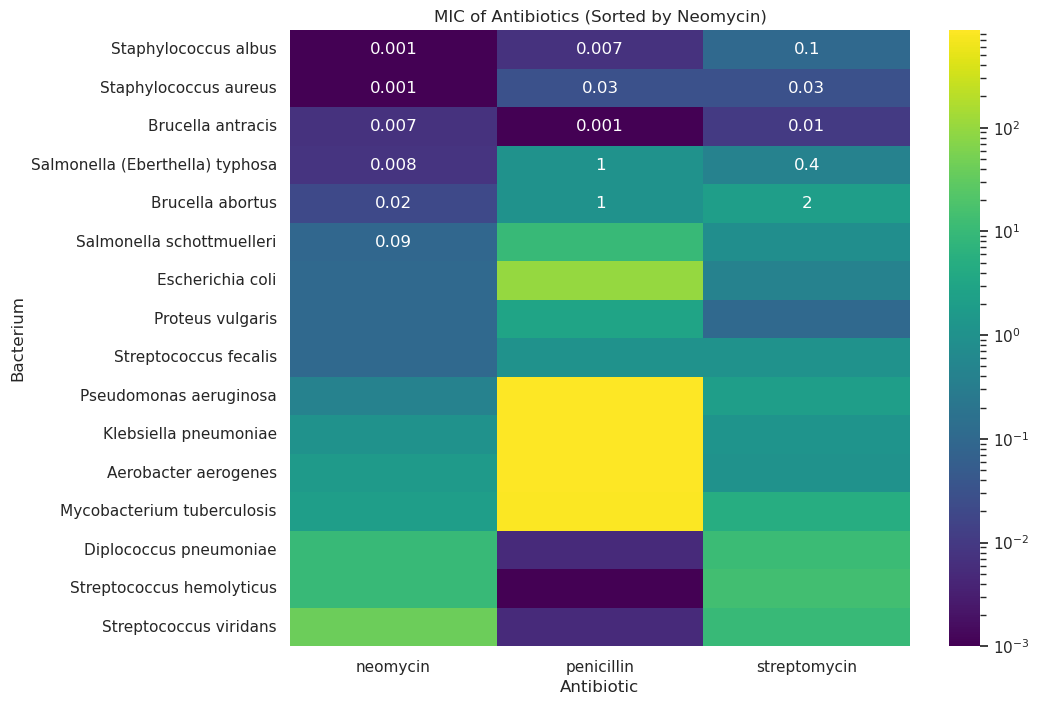

In [73]:
# code your solution here





# 1. Sakhtane jadval (Pivot) mesle tamrine 4.2
pivot_df = antibiotics_df.pivot(index='bacteria', columns='antibiotic', values='mic')

# 2. Moratab kardane radif-ha bar asase sotoone 'neomycin' az koochik be bozorg
pivot_sorted = pivot_df.sort_values(by='neomycin', ascending=True)

# 3. Rasm kardane Heatmap ba Log Scale rooye jadvale moratab shode
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_sorted, annot=True, cmap='viridis', norm=LogNorm())

# 4. Onvan va Label-ha
plt.title('MIC of Antibiotics (Sorted by Neomycin)')
plt.xlabel('Antibiotic')
plt.ylabel('Bacterium')

# 5. Namayeshe nahaee
plt.show()